At the end of the notebook there should be models ready to deploy

In [153]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', 500)

In [154]:
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
import seaborn as sns
rcParams['figure.figsize']=8,5

In [155]:
data_folder = '../data/processed/'

In [156]:
!ls $data_folder

processed_test.csv  processed_train.csv


In [157]:
train_csv = 'processed_train.csv'
test_csv = 'processed_test.csv'
data_folder+train_csv, data_folder+test_csv

('../data/processed/processed_train.csv',
 '../data/processed/processed_test.csv')

# Exploring the datesets

In [158]:
train_df = pd.read_csv(data_folder+train_csv)
test_df = pd.read_csv(data_folder+test_csv)

train_df.shape, test_df.shape

((2000, 89), (500, 79))

In [159]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Component1_fraction,2000.0,0.180690,1.632003e-01,0.000000,0.030000,0.140000,0.290000,0.500000
Component2_fraction,2000.0,0.182910,1.637038e-01,0.000000,0.040000,0.150000,0.300000,0.500000
Component3_fraction,2000.0,0.179820,1.662829e-01,0.000000,0.020000,0.140000,0.290000,0.500000
Component4_fraction,2000.0,0.342090,1.411187e-01,0.010000,0.220000,0.350000,0.500000,0.500000
Component5_fraction,2000.0,0.114490,8.021943e-02,0.000000,0.050000,0.120000,0.180000,0.290000
BlendProperty1,2000.0,-0.016879,9.937866e-01,-2.550897,-0.766128,-0.021089,0.714763,2.856588
BlendProperty2,2000.0,-0.002076,1.004512e+00,-3.079759,-0.735109,0.001684,0.723807,2.769156
BlendProperty3,2000.0,-0.014351,9.993597e-01,-3.041624,-0.624235,0.146135,0.727597,1.638646
BlendProperty4,2000.0,-0.006068,1.009176e+00,-2.835701,-0.783547,-0.028158,0.664659,3.769643
BlendProperty5,2000.0,-0.015249,9.864798e-01,-1.730111,-0.683165,-0.250650,0.358701,3.600439


In [160]:
num_col = list(train_df.describe().columns) 
num_col

['Component1_fraction',
 'Component2_fraction',
 'Component3_fraction',
 'Component4_fraction',
 'Component5_fraction',
 'BlendProperty1',
 'BlendProperty2',
 'BlendProperty3',
 'BlendProperty4',
 'BlendProperty5',
 'BlendProperty6',
 'BlendProperty7',
 'BlendProperty8',
 'BlendProperty9',
 'BlendProperty10',
 'Fraction1_Property1',
 'Fraction1_Property2',
 'Fraction1_Property3',
 'Fraction1_Property4',
 'Fraction1_Property5',
 'Fraction1_Property6',
 'Fraction1_Property7',
 'Fraction1_Property8',
 'Fraction1_Property9',
 'Fraction1_Property10',
 'Fraction2_Property1',
 'Fraction2_Property2',
 'Fraction2_Property3',
 'Fraction2_Property4',
 'Fraction2_Property5',
 'Fraction2_Property6',
 'Fraction2_Property7',
 'Fraction2_Property8',
 'Fraction2_Property9',
 'Fraction2_Property10',
 'Fraction3_Property1',
 'Fraction3_Property2',
 'Fraction3_Property3',
 'Fraction3_Property4',
 'Fraction3_Property5',
 'Fraction3_Property6',
 'Fraction3_Property7',
 'Fraction3_Property8',
 'Fraction3_Pro

# Splitting into training and validation dataset

In [161]:
from sklearn.model_selection import train_test_split

In [162]:
data = train_df[num_col]

In [163]:
target_cols = [ col for col in num_col if "BlendProperty" in col ]
len(target_cols), target_cols

(10,
 ['BlendProperty1',
  'BlendProperty2',
  'BlendProperty3',
  'BlendProperty4',
  'BlendProperty5',
  'BlendProperty6',
  'BlendProperty7',
  'BlendProperty8',
  'BlendProperty9',
  'BlendProperty10'])

In [164]:
X = data.drop(target_cols, axis=1)
y = data[target_cols]

In [165]:
val_size = 0.25 # trian = 75 % and val = 25 %
random_state = 42

In [166]:
X_train, X_val, y_train, y_val = train_test_split( \
            X, y, test_size=val_size, random_state=random_state
        )

In [167]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1500, 79), (500, 79), (1500, 10), (500, 10))

# Training

## Using baseline predictions

In [168]:
y_train.describe()

,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.002434,0.004798,-0.031041,-0.007615,-0.032951,-0.017159,-0.029292,-0.004978,-0.000828,0.008489
std,0.998831,1.013191,1.001244,1.008583,0.968130,1.008985,1.003936,1.000045,0.989869,0.982309
min,-2.550897,-3.079759,-3.041624,-2.726882,-1.730111,-2.808210,-2.994571,-3.621080,-3.292727,-2.209607
25%,-0.737914,-0.719897,-0.670976,-0.797149,-0.693927,-0.712228,-0.668323,-0.714771,-0.682735,-0.723361
50%,-0.007668,-0.004265,0.124421,-0.035413,-0.252455,-0.048242,0.112300,-0.001548,-0.007106,-0.002336
75%,0.756756,0.739762,0.696455,0.682796,0.337779,0.693553,0.673603,0.699638,0.690905,0.690500
max,2.856588,2.769156,1.638646,3.769643,3.507660,3.433292,3.293228,3.340657,3.276199,2.708703


### Fitting the baseline model

In [169]:
y_train_pred = pd.DataFrame(
    {col: [y_train[col].median()] * len(y_train) for col in y_train}
)

In [170]:
print(y_train_pred.shape)  

(1500, 10)


In [171]:
y_train_pred.head()

,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,-0.007668,-0.004265,0.124421,-0.035413,-0.252455,-0.048242,0.1123,-0.001548,-0.007106,-0.002336
1,-0.007668,-0.004265,0.124421,-0.035413,-0.252455,-0.048242,0.1123,-0.001548,-0.007106,-0.002336
2,-0.007668,-0.004265,0.124421,-0.035413,-0.252455,-0.048242,0.1123,-0.001548,-0.007106,-0.002336
3,-0.007668,-0.004265,0.124421,-0.035413,-0.252455,-0.048242,0.1123,-0.001548,-0.007106,-0.002336
4,-0.007668,-0.004265,0.124421,-0.035413,-0.252455,-0.048242,0.1123,-0.001548,-0.007106,-0.002336


In [172]:
y_val_pred = pd.DataFrame(
    {col: [y_train[col].median()] * len(y_val) for col in y_train} # median should be used from the traindataset
)

In [173]:
print(y_val_pred.shape)

(500, 10)


In [174]:
y_val_pred.describe()

,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
count,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,500.000000,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,500.000000
mean,-7.668303e-03,-4.265045e-03,1.244211e-01,-3.541277e-02,-0.252455,-4.824202e-02,1.122995e-01,-1.547709e-03,-7.106367e-03,-0.002336
std,1.736461e-18,8.682304e-19,1.389169e-17,6.945843e-18,0.000000,1.389169e-17,2.778337e-17,2.170576e-19,2.604691e-18,0.000000
min,-7.668303e-03,-4.265045e-03,1.244211e-01,-3.541277e-02,-0.252455,-4.824202e-02,1.122995e-01,-1.547709e-03,-7.106367e-03,-0.002336
25%,-7.668303e-03,-4.265045e-03,1.244211e-01,-3.541277e-02,-0.252455,-4.824202e-02,1.122995e-01,-1.547709e-03,-7.106367e-03,-0.002336
50%,-7.668303e-03,-4.265045e-03,1.244211e-01,-3.541277e-02,-0.252455,-4.824202e-02,1.122995e-01,-1.547709e-03,-7.106367e-03,-0.002336
75%,-7.668303e-03,-4.265045e-03,1.244211e-01,-3.541277e-02,-0.252455,-4.824202e-02,1.122995e-01,-1.547709e-03,-7.106367e-03,-0.002336
max,-7.668303e-03,-4.265045e-03,1.244211e-01,-3.541277e-02,-0.252455,-4.824202e-02,1.122995e-01,-1.547709e-03,-7.106367e-03,-0.002336


## Other models

In [294]:
from sklearn.multioutput import MultiOutputRegressor

### Random Forest

In [295]:
from sklearn.ensemble import RandomForestRegressor

In [296]:
rf_basic = MultiOutputRegressor(RandomForestRegressor(
                n_estimators=100, random_state=42, n_jobs=-1
            ))

In [297]:
model_pkl_file = "random_forrest.pkl"  # to be used whlie saving hte model


### Fitting the other models

In [298]:
# model = lr_basic
model = rf_basic


In [299]:
model.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,n_jobs,None
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [300]:
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

##  Evaluation

In [301]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

In [302]:
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)

In [303]:
print(f'train_r2: {round(train_r2,5)} ,\nval_r2: {round(val_r2,5)}  ,\ntrain_rmse:  {round(train_rmse,5)}  ,\nval_rmse: {round(val_rmse,5)}   ,\nval_mae: {round(val_mae*100,5)}  ')

train_r2: 0.98767 ,
val_r2: 0.91213  ,
train_rmse:  0.11095  ,
val_rmse: 0.29679   ,
val_mae: 22.17256  


The baseline vlaues are as below;
```
train_r2: -0.00975

val_r2: -0.01272

train_rmse: 1.00199

val_rmse: 1.01016

val_mae: 80.2424
```
These values doesn't make sense. Check what does these mean???

In [304]:
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
mape_train_pct = mape_train * 100 # Converting decimals to percentage

In [305]:
# Printing results
print(f'Mean Absolute Percentage Error TRAIN = {mape_train_pct}%')

Mean Absolute Percentage Error TRAIN = 57.67343935282045%


In [306]:
mape_val = mean_absolute_percentage_error(y_val, y_val_pred)
mape_val_pct = mape_val * 100 # Converting decimals to percentage

In [307]:
# Printing results
print(f'Mean Absolute Percentage Error TRAIN = {mape_val_pct}%')

Mean Absolute Percentage Error TRAIN = 480.1847716197364%


# Leaderboard Score

In [308]:
cost = mape_val_pct
test_set = "public_testset"
if test_set=='public_testset':
    ref_cost = 2.72
elif test_set=='private_testset':
    ref_cost = 2.58
cost,ref_cost

(480.1847716197364, 2.72)

In [309]:
calulated_term = 100 - ((90 * cost)/ref_cost)
calulated_term

-15788.466708005983

In [310]:
leaderboardscore = max(10, calulated_term)

In [311]:
print(f'the score relevant to the competition is {leaderboardscore}')

the score relevant to the competition is 10


# Saving trained model

In [312]:
import pickle

In [313]:
model_folder = '../models/'

In [314]:
# model_pkl_file = "linear_reg.pkl"  
model_pkl_file

'random_forrest.pkl'

In [315]:
with open(model_folder+model_pkl_file, 'wb') as file:  
    pickle.dump(model, file)

# Inference

In [316]:
X_train.columns

Index(['Component1_fraction', 'Component2_fraction', 'Component3_fraction',
       'Component4_fraction', 'Component5_fraction', 'Fraction1_Property1',
       'Fraction1_Property2', 'Fraction1_Property3', 'Fraction1_Property4',
       'Fraction1_Property5', 'Fraction1_Property6', 'Fraction1_Property7',
       'Fraction1_Property8', 'Fraction1_Property9', 'Fraction1_Property10',
       'Fraction2_Property1', 'Fraction2_Property2', 'Fraction2_Property3',
       'Fraction2_Property4', 'Fraction2_Property5', 'Fraction2_Property6',
       'Fraction2_Property7', 'Fraction2_Property8', 'Fraction2_Property9',
       'Fraction2_Property10', 'Fraction3_Property1', 'Fraction3_Property2',
       'Fraction3_Property3', 'Fraction3_Property4', 'Fraction3_Property5',
       'Fraction3_Property6', 'Fraction3_Property7', 'Fraction3_Property8',
       'Fraction3_Property9', 'Fraction3_Property10', 'Fraction4_Property1',
       'Fraction4_Property2', 'Fraction4_Property3', 'Fraction4_Property4',
       'F

In [317]:
len(target_cols),target_cols

(10,
 ['BlendProperty1',
  'BlendProperty2',
  'BlendProperty3',
  'BlendProperty4',
  'BlendProperty5',
  'BlendProperty6',
  'BlendProperty7',
  'BlendProperty8',
  'BlendProperty9',
  'BlendProperty10'])

In [318]:
# test_num_col =  list(set(X_train.columns) - set(target_cols))
# len(test_num_col),test_num_col

In [319]:
X_test = test_df[X_train.columns]
X_test.shape

(500, 79)

## Loading the model

In [320]:
filename = model_folder + model_pkl_file
filename


'../models/random_forrest.pkl'

In [321]:
loaded_model = pickle.load(open(filename, 'rb'))

In [322]:
loaded_model

,estimator,RandomForestR...ndom_state=42)
,n_jobs,None
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


## using baseline predictions

In [323]:
# y_test_pred = pd.DataFrame(
#     {col: [y_train[col].median()] * len(X_test) for col in y_train}
# )

In [324]:
# print(y_test_pred.shape)

## Using Random forest

In [325]:
y_test_pred = model.predict(X_test)

#  Preparing the submission file



In [326]:
pwd

'/home/pkn/workspace/side_projects/he_shellai_2025/notebooks'

In [327]:
raw_test_df = pd.read_csv('../data/raw/test.csv')
raw_test_df.shape

(500, 56)

In [328]:
test_df['ID'] =raw_test_df['ID']

In [329]:
test_df[target_cols] = y_test_pred
test_df.shape

(500, 90)

In [330]:
test_df.columns

Index(['Component1_fraction', 'Component2_fraction', 'Component3_fraction',
       'Component4_fraction', 'Component5_fraction', 'Fraction1_Property1',
       'Fraction1_Property2', 'Fraction1_Property3', 'Fraction1_Property4',
       'Fraction1_Property5', 'Fraction1_Property6', 'Fraction1_Property7',
       'Fraction1_Property8', 'Fraction1_Property9', 'Fraction1_Property10',
       'Fraction2_Property1', 'Fraction2_Property2', 'Fraction2_Property3',
       'Fraction2_Property4', 'Fraction2_Property5', 'Fraction2_Property6',
       'Fraction2_Property7', 'Fraction2_Property8', 'Fraction2_Property9',
       'Fraction2_Property10', 'Fraction3_Property1', 'Fraction3_Property2',
       'Fraction3_Property3', 'Fraction3_Property4', 'Fraction3_Property5',
       'Fraction3_Property6', 'Fraction3_Property7', 'Fraction3_Property8',
       'Fraction3_Property9', 'Fraction3_Property10', 'Fraction4_Property1',
       'Fraction4_Property2', 'Fraction4_Property3', 'Fraction4_Property4',
       'F

In [331]:
req_sub_cols = ['ID'] + target_cols
len(req_sub_cols)

11

In [332]:
test_df[req_sub_cols].head()

,ID,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,1,-0.258853,0.177290,0.558395,0.417748,0.199848,0.552138,0.554155,0.455060,-0.278948,0.540143
1,2,-0.620778,-0.341924,-1.221320,-0.007374,-0.753784,-0.107790,-1.199947,-1.260779,-0.168142,0.279323
2,3,1.326406,0.684667,0.703301,0.659110,2.244416,1.517334,0.665919,1.458209,0.080716,1.990337
3,4,0.055937,0.566264,0.640967,-0.241517,2.148889,-0.187461,0.696813,1.269187,0.728821,-0.622394
4,5,0.301466,-0.627266,1.232971,0.301891,2.411947,0.079669,1.165164,-0.359949,-0.689838,0.924630


<Axes: ylabel='Density'>

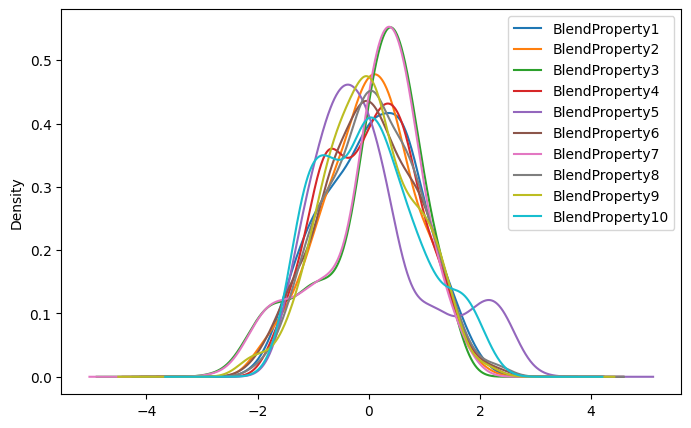

In [333]:
test_df[target_cols].plot.density()

In [334]:
submission_folder = '../data/submission/'

In [335]:
file_name = 'rf_basic_multi'

In [336]:
test_df[req_sub_cols].to_csv(submission_folder+file_name+'.csv',index=False)